# Notebook 05 — Modelli panel finali

## Obiettivi
Questo notebook rappresenta la fase conclusiva dell'analisi quantitativa. Integra tutte le metriche
longitudinali costruite nei notebook precedenti (`01_preproc`, `03_geographic_diversity`,
`04_robustness`) in un unico panel utente–anno, stima i modelli a effetti fissi (FE) definitivi per
ciascuna dimensione della diversity, confronta l'evoluzione temporale delle diverse dimensioni e ne
propone un'interpretazione congiunta rispetto alla domanda di ricerca.

Le quattro metriche considerate:
- **Genre Diversity** (Shannon Entropy sui 19 macro-generi)
- **Genre Novelty** (quota di generi nuovi per anno)
- **Geographic Diversity** (Shannon Entropy sui paesi di produzione)
- **Genome Tag Novelty** (quota di Genome Tags nuovi per anno — metrica granulare, vedi `04_robustness`
  per la discussione dei suoi limiti di copertura)

**Nota importante sui campioni.** `entropy` e `novelty_pct` sono calcolati sul campione stratificato di
10.000 utenti già filtrato in `02_EDA` (≥5 rating/anno, ≥2 anni attivi). `geo_entropy` e `tag_novelty`
sono invece calcolati sull'intera popolazione di rating, senza questi due filtri. Il merge tra i dataset
va quindi verificato esplicitamente (tasso di match, NaN), non dato per scontato.

#### Import delle librerie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

print("Ambiente configurato correttamente")

Ambiente configurato correttamente


#### Definizione dei path

In [2]:
project_root = Path.cwd().parent

data_path = project_root / "data"
processed_path = data_path / "processed"
figures_path = project_root / "figures"
figures_path.mkdir(exist_ok=True)

print("Project root:", project_root)
print("Processed path:", processed_path)
print("Figures path:", figures_path)

Project root: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens
Processed path: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/data/processed
Figures path: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/figures


### Caricamento dei dataset longitudinali

Vengono caricati i tre dataset costruiti nei notebook precedenti: il panel dei generi (base, già
filtrato e con `active_year`/`log_ratings` pronti), il panel geografico e il panel dei Genome Tags.

In [3]:
genre_path = processed_path / "sample_users_10k.parquet"
geo_path = processed_path / "user_year_geo_longitudinal.parquet"
genome_path = processed_path / "user_year_genome_longitudinal.parquet"

genre_df = pd.read_parquet(genre_path)
geo_df = pd.read_parquet(geo_path)
genome_df = pd.read_parquet(genome_path)

print("Genre panel (base):", genre_df.shape)
print("Geo panel:", geo_df.shape)
print("Genome panel:", genome_df.shape)

Genre panel (base): (35624, 33)
Geo panel: (240347, 4)
Genome panel: (240303, 4)


### Costruzione del panel integrato

Uso `genre_df` (il campione stratificato di 10k utenti) come base, e aggiungo `geo_entropy` / `n_countries` e `tag_novelty` / `n_tags` tramite left join su `[userId, year]`. Il left join preserva tutte le righe della base anche quando manca una corrispondenza (es. un utente-anno senza film con Genome Tags), che si traduce in `NaN` sulla metrica corrispondente.

In [4]:
panel = genre_df.merge(
    geo_df[["userId", "year", "geo_entropy", "n_countries"]],
    on=["userId", "year"],
    how="left"
)

panel = panel.merge(
    genome_df[["userId", "year", "tag_novelty", "n_tags"]],
    on=["userId", "year"],
    how="left"
)

print("Panel integrato:", panel.shape)
panel.head()

Panel integrato: (35624, 37)


,userId,year,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,entropy,novelty_pct,n_ratings_year,total_ratings,active_year,log_ratings,entropy_dm,active_year_dm,log_ratings_dm,genres_seen_this_year,n_ratings,activity_group,geo_entropy,n_countries,tag_novelty,n_tags
0,3,2015,204.0,129.0,29.0,29.0,106.0,67.0,3.0,143.0,46.0,2.0,33.0,45.0,5.0,36.0,48.0,145.0,153.0,12.0,4.0,3.626402,1.0,1239,1239.0,1,7.122867,0.044970,-1.5,1.335940,19,656,High,1.902675,23.0,1.000000,1052
1,3,2016,15.0,9.0,2.0,2.0,7.0,6.0,0.0,11.0,7.0,1.0,0.0,5.0,0.0,2.0,2.0,7.0,10.0,3.0,0.0,3.585458,0.0,89,89.0,2,4.499810,0.004026,-0.5,-1.287117,15,656,High,0.969918,4.0,0.004525,663
2,3,2017,34.0,18.0,6.0,2.0,12.0,14.0,0.0,24.0,6.0,1.0,5.0,13.0,0.0,10.0,1.0,42.0,25.0,6.0,1.0,3.515761,0.0,220,220.0,3,5.398163,-0.065671,0.5,-0.388764,17,656,High,2.315034,12.0,0.010403,769
3,3,2019,81.0,42.0,13.0,15.0,51.0,45.0,0.0,54.0,19.0,1.0,7.0,18.0,1.0,12.0,9.0,30.0,51.0,5.0,3.0,3.598108,0.0,457,457.0,4,6.126869,0.016675,1.5,0.339942,18,656,High,1.913359,12.0,0.013714,875
4,5,1996,5.0,9.0,3.0,4.0,21.0,8.0,0.0,23.0,1.0,0.0,2.0,3.0,4.0,5.0,7.0,3.0,12.0,2.0,4.0,3.608284,1.0,116,116.0,1,4.762174,0.108746,-0.5,-0.071550,17,101,Low,0.394684,3.0,1.000000,637


#### Verifica del tasso di match

In [5]:
match_geo = panel["geo_entropy"].notna().mean()
match_genome = panel["tag_novelty"].notna().mean()

print(f"Quota di utente-anno con geo_entropy disponibile: {match_geo:.1%}")
print(f"Quota di utente-anno con tag_novelty disponibile: {match_genome:.1%}")

print()
print("Valori mancanti per colonna:")
print(panel[["entropy", "novelty_pct", "geo_entropy", "tag_novelty"]].isna().sum())

Quota di utente-anno con geo_entropy disponibile: 100.0%
Quota di utente-anno con tag_novelty disponibile: 100.0%

Valori mancanti per colonna:
entropy        0
novelty_pct    0
geo_entropy    2
tag_novelty    0
dtype: int64


**Interpretazione attesa:** il match su `geo_entropy` dovrebbe essere molto alto (il mapping paese copre
la maggior parte dei rating). Il match su `tag_novelty` sarà invece più basso, coerentemente con il limite
di copertura discusso in `04_robustness` (solo il 23.4% dei film ha Genome Tags a livello di catalogo, pur
coprendo il 98.7% dei rating totali. La copertura utente-anno può comunque scendere se in un anno un
utente ha visto solo film senza Genome Tags). I `NaN` non vengono riempiti con zero: un valore mancante
significa "nessun film valutabile con questa metrica in quell'anno", non "diversità nulla", verrebbero
altrimenti introdotti zeri artificiali che distorcerebbero le regressioni. Le righe con `NaN` sulla
metrica dipendente vengono semplicemente escluse dal modello specifico (gestito automaticamente da
`statsmodels`, dal `dropna`), senza eliminarle dal panel per le altre metriche.

#### Salvataggio panel integrato

In [6]:
output_path = processed_path / "panel_finale.parquet"
panel.to_parquet(output_path, index=False)
print("Panel integrato salvato in:", output_path)

Panel integrato salvato in: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/data/processed/panel_finale.parquet


### Statistiche descrittive del panel finale

In [7]:
metrics = ["entropy", "novelty_pct", "geo_entropy", "tag_novelty"]
panel[metrics].describe()

,entropy,novelty_pct,geo_entropy,tag_novelty
count,35624.000000,35624.000000,35622.000000,35624.000000
mean,3.335192,0.299939,1.509975,0.322451
std,0.405858,0.442189,0.611844,0.432777
min,-0.000000,0.000000,0.000000,0.000000
25%,3.199220,0.000000,1.129167,0.009287
50%,3.460016,0.000000,1.508574,0.044538
75%,3.608544,1.000000,1.903605,1.000000
max,3.941785,1.000000,4.180929,1.000000


### Relazione tra le dimensioni della diversity

Prima di stimare i modelli separati, è utile chiedersi se le quattro metriche si muovano insieme per lo
stesso utente-anno (un utente che diversifica i generi diversifica anche i paesi?) o se catturino aspetti
sostanzialmente indipendenti del comportamento di consumo.

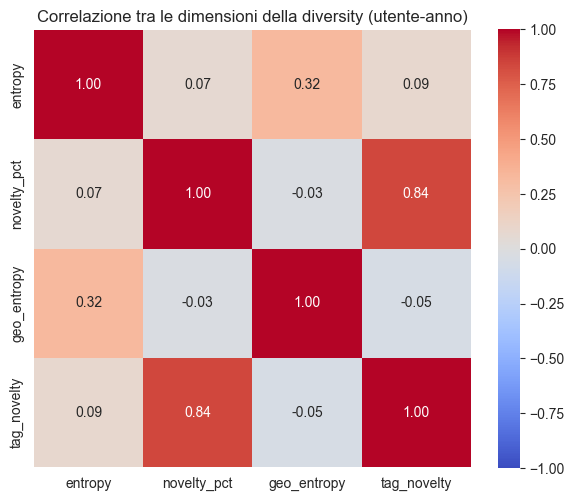

,entropy,novelty_pct,geo_entropy,tag_novelty
entropy,1.000000,0.067806,0.323958,0.085426
novelty_pct,0.067806,1.000000,-0.031129,0.839974
geo_entropy,0.323958,-0.031129,1.000000,-0.053422
tag_novelty,0.085426,0.839974,-0.053422,1.000000


In [8]:
p2 = panel[panel["active_year"] >= 2]
corr_matrix = p2[metrics].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlazione tra le dimensioni della diversity (utente-anno)")
plt.tight_layout()
plt.savefig(figures_path / "correlation_diversity_metrics.png", dpi=200)
plt.show()

corr_matrix

**Risultato**<br>
La correlazione è calcolata escludendo il primo anno di attività
(`active_year >= 2`), dove la novelty vale 1 per costruzione e gonfierebbe
artificialmente le associazioni (con il primo anno la correlazione tra le due
novelty risultava 0.993, e quella tra entropy e novelty circa 0.26-0.27).
Escludendolo, 
 `entropy` è correlata in modo moderato con `geo_entropy` (r ≈ 0.32) e in modo quasi nullo con le due novelty (r ≈ 0.07-0.09): divesrità e novelty risultano dimensioni distinte. <br>
 
 `novelty_pct` e `tag_novelty` risultano particolarmente associate (r = 0.84), ma non coincidono: la granularità dei Genome
Tags introduce differenze non trascurabili rispetto ai 19 generi.

In [9]:
p2[["novelty_pct", "tag_novelty"]].describe()

,novelty_pct,tag_novelty
count,25624.000000,25624.000000
mean,0.026869,0.058107
std,0.078455,0.106940
min,0.000000,0.000000
25%,0.000000,0.005319
50%,0.000000,0.018893
75%,0.000000,0.058051
max,0.882353,0.924331


### Traiettorie medie per anno di attività (analisi descrittiva)

Prima dei modelli a effetti fissi, si osserva la traiettoria grezza (senza controlli) delle quattro metriche in funzione di `active_year`, per un primo sguardo generale.

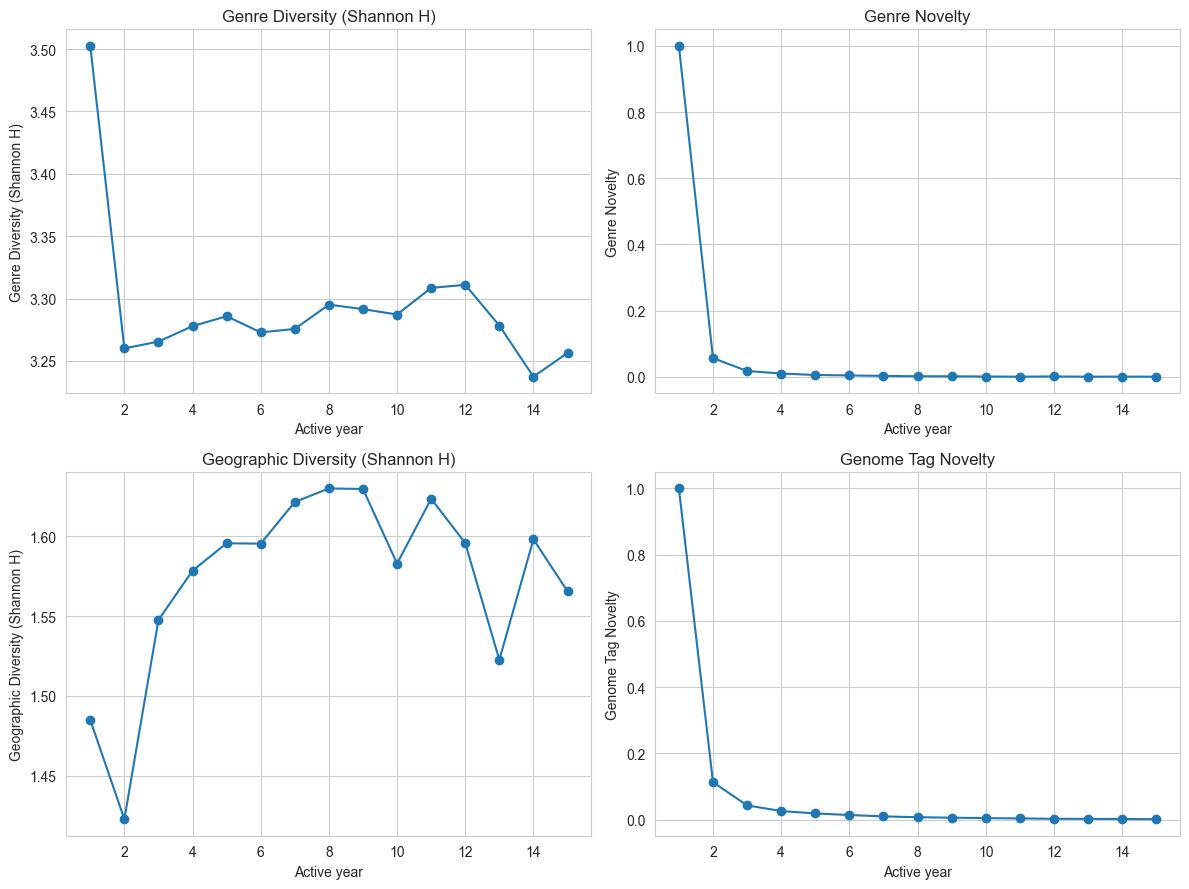

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

trajectories = {
    "entropy": "Genre Diversity (Shannon H)",
    "novelty_pct": "Genre Novelty",
    "geo_entropy": "Geographic Diversity (Shannon H)",
    "tag_novelty": "Genome Tag Novelty",
}

for ax, (col, label) in zip(axes.flat, trajectories.items()):
    traj = panel.groupby("active_year")[col].mean()
    # per active_year troppo alti il numero di utenti si assottiglia molto: limitiamo a active_year <= 15
    traj = traj[traj.index <= 15]
    ax.plot(traj.index, traj.values, marker="o")
    ax.set_title(label)
    ax.set_xlabel("Active year")
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig(figures_path / "trajectories_active_year.png", dpi=200)
plt.show()

### Modelli a effetti fissi (FE)

Per ciascuna delle quattro metriche si stima lo stesso modello a effetti fissi utente (demeaning per
utente + errori standard clustered per utente + controllo per anno di calendario) già usato in `02_EDA`
e `04_robustness`

**Entropy** e **geo_entropy** vengono stimati sul panel completo (ogni anno attivo è un'osservazione
valida). **novelty_pct** e **tag_novelty** vengono invece stimati solo su `active_year >= 2`, perché al
primo anno di attività la novelty è per costruzione ~100%, e includerla non introdurrebbe un vero effetto temporale.

In [11]:
def fit_fe_model(df, outcome, cluster_col="userId", year_col="year", extra_controls=("active_year", "log_ratings")):
    """Stima un modello a effetti fissi utente (demeaning) con errori standard clustered."""
    d = df.dropna(subset=[outcome, *extra_controls]).copy()

    cols_to_dm = [outcome, *extra_controls]
    for col in cols_to_dm:
        d[f"{col}_dm"] = d[col] - d.groupby(cluster_col)[col].transform("mean")

    rhs = " + ".join(f"{c}_dm" for c in extra_controls)
    formula = f"{outcome}_dm ~ {rhs} + C({year_col})"

    model = smf.ols(formula, data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d[cluster_col]}
    )
    return model, d


model_entropy_final, d_entropy = fit_fe_model(panel, "entropy")
model_geo_final, d_geo = fit_fe_model(panel, "geo_entropy")

panel_novelty = panel[panel["active_year"] >= 2].copy()
model_novelty_final, d_novelty = fit_fe_model(panel_novelty, "novelty_pct")
model_genome_final, d_genome = fit_fe_model(panel_novelty, "tag_novelty")

print("REGRESSIONE FE — Genre Diversity (entropy)")
print(model_entropy_final.summary().tables[1])

REGRESSIONE FE — Genre Diversity (entropy)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0543      0.007      7.785      0.000       0.041       0.068
C(year)[T.1997]    -0.0928      0.013     -7.115      0.000      -0.118      -0.067
C(year)[T.1998]    -0.0772      0.014     -5.664      0.000      -0.104      -0.050
C(year)[T.1999]    -0.0467      0.010     -4.891      0.000      -0.065      -0.028
C(year)[T.2000]    -0.0797      0.009     -9.196      0.000      -0.097      -0.063
C(year)[T.2001]    -0.0842      0.009     -9.534      0.000      -0.102      -0.067
C(year)[T.2002]    -0.0491      0.009     -5.483      0.000      -0.067      -0.032
C(year)[T.2003]    -0.0729      0.009     -8.260      0.000      -0.090      -0.056
C(year)[T.2004]    -0.0603      0.009     -6.985      0.000      -0.077      -0.043
C(year)[T.2005]    -0.0480      0

In [12]:
print("REGRESSIONE FE — Geographic Diversity (geo_entropy)")
print(model_geo_final.summary().tables[1])

REGRESSIONE FE — Geographic Diversity (geo_entropy)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0842      0.011     -7.997      0.000      -0.105      -0.064
C(year)[T.1997]     0.1564      0.020      7.895      0.000       0.118       0.195
C(year)[T.1998]    -0.0300      0.024     -1.237      0.216      -0.078       0.018
C(year)[T.1999]    -0.0648      0.014     -4.616      0.000      -0.092      -0.037
C(year)[T.2000]    -0.0485      0.013     -3.608      0.000      -0.075      -0.022
C(year)[T.2001]     0.1115      0.014      7.761      0.000       0.083       0.140
C(year)[T.2002]     0.1411      0.015      9.638      0.000       0.112       0.170
C(year)[T.2003]     0.1482      0.014     10.612      0.000       0.121       0.176
C(year)[T.2004]     0.0457      0.014      3.322      0.001       0.019       0.073
C(year)[T.2005]     0.08

In [13]:
print("REGRESSIONE FE — Genre Novelty (novelty_pct)")
print(model_novelty_final.summary().tables[1])

REGRESSIONE FE — Genre Novelty (novelty_pct)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -3.645e-05   3.65e-05     -0.999      0.318      -0.000     3.5e-05
C(year)[T.1998]     0.0218      0.005      4.129      0.000       0.011       0.032
C(year)[T.1999]    -0.0008      0.004     -0.186      0.853      -0.009       0.007
C(year)[T.2000]     0.0131      0.002      6.201      0.000       0.009       0.017
C(year)[T.2001]     0.0035      0.002      1.941      0.052   -3.41e-05       0.007
C(year)[T.2002]    -0.0014      0.001     -0.950      0.342      -0.004       0.001
C(year)[T.2003]    -0.0020      0.002     -1.200      0.230      -0.005       0.001
C(year)[T.2004]    -0.0061      0.001     -5.290      0.000      -0.008      -0.004
C(year)[T.2005]    -0.0047      0.001     -4.490      0.000      -0.007      -0.003
C(year)[T.2006]    -0.0024     

In [14]:
print("REGRESSIONE FE — Genome Tag Novelty (tag_novelty)")
print(model_genome_final.summary().tables[1])

REGRESSIONE FE — Genome Tag Novelty (tag_novelty)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -6.109e-05   6.11e-05     -1.000      0.317      -0.000    5.87e-05
C(year)[T.1998]     0.0384      0.008      4.666      0.000       0.022       0.055
C(year)[T.1999]     0.0085      0.007      1.289      0.198      -0.004       0.022
C(year)[T.2000]     0.0195      0.002      8.636      0.000       0.015       0.024
C(year)[T.2001]     0.0079      0.002      4.143      0.000       0.004       0.012
C(year)[T.2002]    -0.0034      0.002     -2.218      0.027      -0.006      -0.000
C(year)[T.2003]    -0.0057      0.002     -3.247      0.001      -0.009      -0.002
C(year)[T.2004]    -0.0072      0.001     -5.234      0.000      -0.010      -0.004
C(year)[T.2005]    -0.0104      0.001     -8.124      0.000      -0.013      -0.008
C(year)[T.2006]    -0.0057

### Tabella riassuntiva dei coefficienti

Raccolgo in un'unica tabella i coefficienti su `active_year_dm` (l'effetto di interesse: come cambia ciascuna dimensione della diversity al crescere dell'anzianità sulla piattaforma, a parità di volume di consumo e di anno di calendario), con intervalli di confidenza al 95% e numero di osservazioni usate in ciascun modello.

In [15]:
def summarize_model(model, name, n_obs):
    coef = model.params["active_year_dm"]
    se = model.bse["active_year_dm"]
    pval = model.pvalues["active_year_dm"]
    ci_low, ci_high = model.conf_int().loc["active_year_dm"]
    return {
        "metrica": name,
        "coef_active_year": coef,
        "std_err": se,
        "p_value": pval,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "n_obs": n_obs,
    }

summary_table = pd.DataFrame([
    summarize_model(model_entropy_final, "Genre Diversity (H)", len(d_entropy)),
    summarize_model(model_geo_final, "Geographic Diversity (H)", len(d_geo)),
    summarize_model(model_novelty_final, "Genre Novelty", len(d_novelty)),
    summarize_model(model_genome_final, "Genome Tag Novelty", len(d_genome)),
])
summary_table

,metrica,coef_active_year,std_err,p_value,ci_95_low,ci_95_high,n_obs
0,Genre Diversity (H),0.006475,0.000849,2.448643e-14,0.004811,0.008140,35624
1,Geographic Diversity (H),0.021270,0.001796,2.299562e-32,0.017750,0.024790,35622
2,Genre Novelty,-0.002006,0.000167,3.578484e-33,-0.002334,-0.001678,25624
3,Genome Tag Novelty,-0.004258,0.000256,3.319999e-62,-0.004759,-0.003756,25624


#### Forest plot: confronto visivo dei quattro effetti

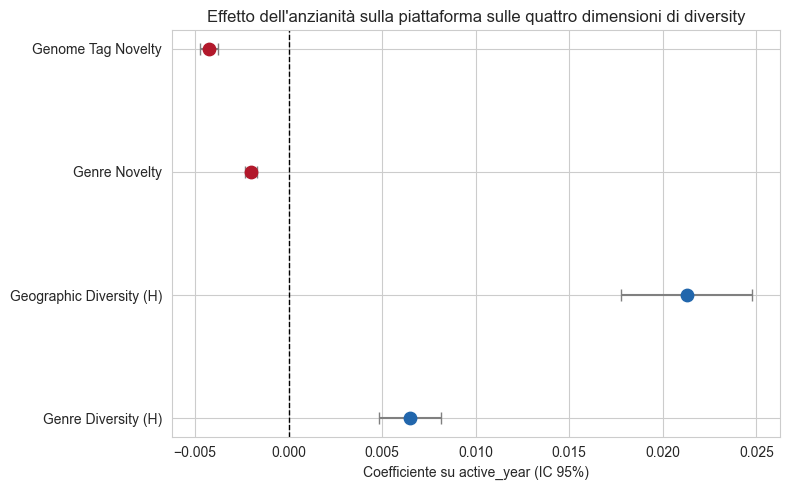

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = np.arange(len(summary_table))
errors = [
    summary_table["coef_active_year"] - summary_table["ci_95_low"],
    summary_table["ci_95_high"] - summary_table["coef_active_year"],
]

colors = ["#2166ac" if c > 0 else "#b2182b" for c in summary_table["coef_active_year"]]

ax.errorbar(
    summary_table["coef_active_year"], y_pos,
    xerr=errors, fmt="o", capsize=4, color="black", ecolor="gray"
)
for i, c in enumerate(colors):
    ax.scatter(summary_table["coef_active_year"].iloc[i], y_pos[i], color=c, s=80, zorder=3)

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(summary_table["metrica"])
ax.set_xlabel("Coefficiente su active_year (IC 95%)")
ax.set_title("Effetto dell'anzianità sulla piattaforma sulle quattro dimensioni di diversity")
plt.tight_layout()
plt.savefig(figures_path / "forest_plot_active_year.png", dpi=200)
plt.show()

### Significatività statistica vs rilevanza pratica

Con decine di migliaia di osservazioni, anche coefficienti molto piccoli risultano statisticamente significativi. Prima di trarre conclusioni sulla domanda di ricerca, è quindi necessario chiedersi quanto ciascun effetto sia rilevante **in pratica**: che variazione implica, nell'arco di una permanenza tipica sulla piattaforma, rispetto al range osservabile della metrica?

In [17]:
HORIZON_YEARS = 10  # orizzonte di confronto: 10 anni di attività

effect_size_table = summary_table.copy()
effect_size_table["variazione_attesa_10y"] = effect_size_table["coef_active_year"] * HORIZON_YEARS

metric_ranges = {
    "Genre Diversity (H)": panel["entropy"],
    "Geographic Diversity (H)": panel["geo_entropy"],
    "Genre Novelty": panel["novelty_pct"],
    "Genome Tag Novelty": panel["tag_novelty"],
}

effect_size_table["dev_standard_metrica"] = [
    metric_ranges[m].std() for m in effect_size_table["metrica"]
]
effect_size_table["variazione_in_dev_standard"] = (
    effect_size_table["variazione_attesa_10y"] / effect_size_table["dev_standard_metrica"]
)

effect_size_table[[
    "metrica", "coef_active_year", "variazione_attesa_10y",
    "dev_standard_metrica", "variazione_in_dev_standard"
]]

,metrica,coef_active_year,variazione_attesa_10y,dev_standard_metrica,variazione_in_dev_standard
0,Genre Diversity (H),0.006475,0.064754,0.405858,0.159548
1,Geographic Diversity (H),0.021270,0.212701,0.611844,0.347639
2,Genre Novelty,-0.002006,-0.020059,0.442189,-0.045363
3,Genome Tag Novelty,-0.004258,-0.042578,0.432777,-0.098383


L'ultima colonna esprime la variazione attesa su 10 anni di attività in termini di deviazioni standard della metrica stessa (una sorta di "effect size" standardizzato).
- Valori sotto 0.2 indicano un effetto piccolo anche cumulato su un decennio
- Valori più alti indicano un effetto che comincia a essere visibile anche a livello individuale, non solo in aggregato su campioni
enormi.

**Applicato ai risultati ottenuti:** la Geographic Diversity è l'unica delle quattro metriche a superare la soglia di 0.2 (≈0.35 deviazioni standard su 10 anni).
E' quindi l'unico effetto abbastanza grande da
essere potenzialmente percepibile anche a livello di singolo utente, non solo in aggregato.  
Genre Diversity (0.16), Genre Novelty (-0.05) e Genome Tag Novelty (-0.10) restano tutti sotto soglia: reali e statisticamente solidi, ma di rilevanza pratica modesta anche su un orizzonte di 10 anni.

### Robustezza aggiuntiva: modello a effetti misti (mixed-effects)

Eseguo la verifica tramite modelli a effetti misti (mixed-effects), come cross-check per la metrica principale (Genre Diversity): un'intercetta casuale per utente cattura l'eterogeneità individuale di base, mentre `active_year` resta un effetto fisso di interesse. Se il segno e l'ordine di grandezza del coefficiente sono coerenti con il modello FE via demeaning, il risultato principale può considerarsi robusto anche alla scelta della tecnica di stima.

In [18]:
mixed_data = panel.dropna(subset=["entropy", "active_year", "log_ratings"]).copy()

mixed_model = sm.MixedLM.from_formula(
    "entropy ~ active_year + log_ratings + C(year)",
    groups="userId",
    data=mixed_data
)
mixed_result = mixed_model.fit(reml=True)

print("MIXED-EFFECTS MODEL — Genre Diversity (entropy), intercetta casuale per utente")
print(mixed_result.summary().tables[1].loc[["active_year", "log_ratings"]] if hasattr(mixed_result.summary().tables[1], "loc") else mixed_result.summary().tables[1])

MIXED-EFFECTS MODEL — Genre Diversity (entropy), intercetta casuale per utente
             Coef. Std.Err.        z  P>|z| [0.025 0.975]
active_year  0.006    0.001    9.533  0.000  0.005  0.007
log_ratings  0.216    0.001  190.167  0.000  0.214  0.219


In [19]:
print(f"Coefficiente active_year — FE (demeaning): {model_entropy_final.params['active_year_dm']:.4f}")
print(f"Coefficiente active_year — Mixed-effects: {mixed_result.params['active_year']:.4f}")

Coefficiente active_year — FE (demeaning): 0.0065
Coefficiente active_year — Mixed-effects: 0.0060


I due coefficienti hanno segno concorde e ordine di grandezza simile, questo vuol dire che il risultato principale sulla diversità dei generi è robusto anche alla scelta tra FE-demeaning e mixed-effects.

### Interpretazione congiunta e conclusioni

Guardando i quattro modelli insieme invece che uno alla volta, emerge che:

- **Genre Diversity** e **Geographic Diversity** tendono ad aumentare con l'anzianità sulla piattaforma: gli utenti più "vecchi" mescolano generi e paesi di origine dei film in modo più equilibrato, non meno.
- **Genre Novelty** e **Genome Tag Novelty** diminuiscono con l'anzianità: gli utenti scoprono sempre meno categorie *nuove* (generi o tag) rispetto a quelle già viste, un pattern coerente con un effetto soffitto già discusso in `02_EDA` e approfondito in `04_robustness`. Le due metriche di novelty sono peraltro correlate a r = 0.84 (escluso il primo anno): condividono gran parte della dinamica di saturazione, pur non coincidendo.
- Tra le quattro dimensioni, solo la **Geographic Diversity** ha un effect size che supera la soglia di rilevanza pratica su 10 anni (~0.35 deviazioni standard): è l'unico segnale abbastanza ampio da essere potenzialmente percepibile a livello di singolo utente, non solo in aggregato.

Questi due risultati non sono contraddittori: descrivono due fenomeni diversi. Un utente può continuare a mescolare in modo sempre più equilibrato ciò che già conosce (diversity in aumento) pur smettendo di esplorare categorie mai viste prima (novelty in calo). 
La domanda "gli algoritmi ci restringono?" ha quindi una risposta diversa a seconda di quale delle due nozioni di diversità si intende: la varietà del consumo corrente non sembra restringersi, anzi... ma la propensione a scoprire contenuti realmente nuovi sì.

**Attenzione alla significatività pratica:** anche i coefficienti confermati come statisticamente robusti in `04_robustness` restano piccoli se convertiti in unità interpretabili (deviazioni standard della metrica su un orizzonte di 10 anni). Il risultato va quindi presentato con questa cautela: la direzione dell'effetto è solida, la sua magnitudine nella vita di un singolo utente resta modesta.

**Limiti:**
- La metrica di Genome Tag Novelty eredita il bias verso i consumi mainstream discusso in `04_robustness` (Genome Tags disponibili solo per il 23.
  4% dei film, seppur al 98.7% dei rating)
- Nessuna rottura strutturale (change-point) è stata rilevata nella traiettoria della diversità dei generi (`04_robustness`): l'evoluzione 
  osservata è un trend graduale, non un salto legato a un evento specifico (es. un cambiamento nell'algoritmo di raccomandazione), e i dati MovieLens non permettono di distinguere causalmente un effetto "algoritmo" da una semplice evoluzione naturale delle preferenze dell'utente nel
  tempo
- Il confronto tra le quattro metriche richiede cautela nell'interpretazione causale: correlazioni a livello utente-anno non implicano che le 
  dimensioni condividano lo stesso meccanismo sottostante.